# Credit Rating Prediction Guide
## Using the Trained XGBoost Model for Investment-Grade Classification

**Business Objective:** Predict whether a company will receive an investment-grade rating (AAA-BBB) or junk-grade rating (BB-D) based on financial ratios.

**Model Performance:** 82.8% accuracy on holdout data

---

## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import joblib
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Load Model and Metadata

In [2]:
# Define paths
MODEL_PATH = "models/company_credit_rating_with_financial_ratios_final_model.joblib"
SCALER_PATH = "models/company_credit_rating_with_financial_ratios_scaler.joblib"
METADATA_PATH = "model_metadata.json"
HOLDOUT_REPORT_PATH = "reports/company_credit_rating_with_financial_ratios_holdout_report.json"

# Load model and scaler
model = joblib.load(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)

# Load metadata
with open(METADATA_PATH, 'r') as f:
    metadata = json.load(f)

# Load holdout report
with open(HOLDOUT_REPORT_PATH, 'r') as f:
    holdout_report = json.load(f)

print("✓ Model loaded successfully")
print(f"✓ Model accuracy on holdout data: {metadata['benchmark_holdout_acc']:.2%}")
print(f"✓ Number of features: {len(metadata['feature_columns'])}")

✓ Model loaded successfully
✓ Model accuracy on holdout data: 82.83%
✓ Number of features: 16


## 3. Feature Importance Analysis

**Business Value:** Understanding which financial ratios drive credit ratings helps identify key risk factors and focus areas for credit improvement.

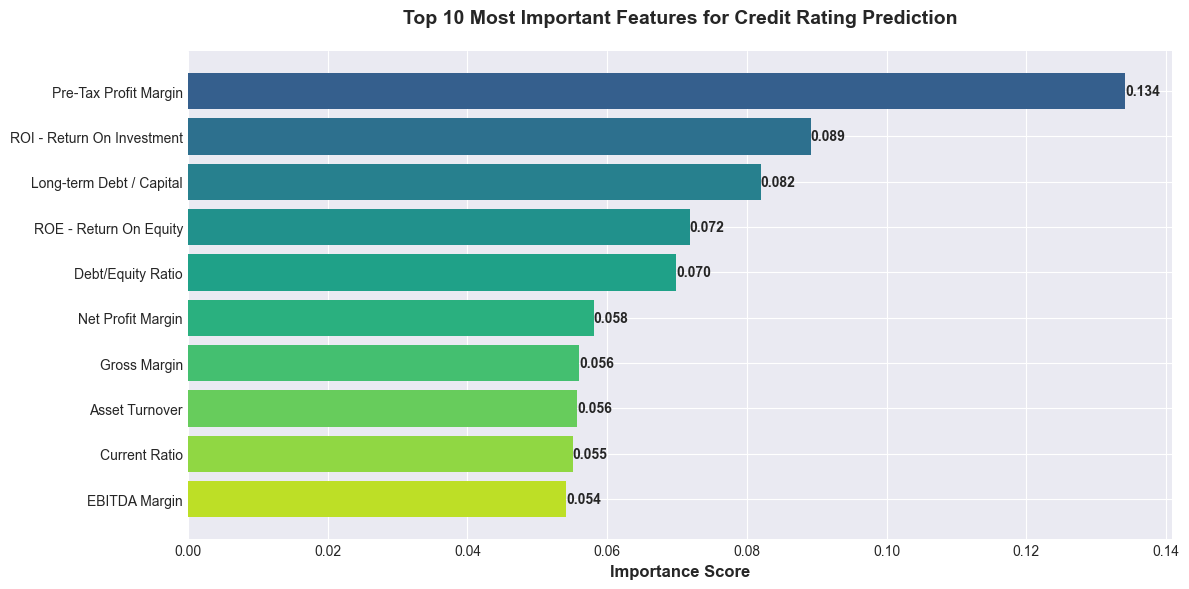


📊 Key Insights:
   • Pre-Tax Profit Margin is the most important predictor (13.4%)
   • Top 3 features account for 30.5% of predictive power
   • Profitability metrics dominate the top features


In [4]:
# Extract feature importances
feature_importances = pd.DataFrame(
    metadata['feature_importances_top20'],
    columns=['Feature', 'Importance']
)

# Visualize top 10 features
fig, ax = plt.subplots(figsize=(12, 6))
top_10 = feature_importances.head(10)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_10)))

bars = ax.barh(top_10['Feature'], top_10['Importance'], color=colors)
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Most Important Features for Credit Rating Prediction', 
             fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
            f'{width:.3f}', ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Key Insights:")
print(f"   • {top_10.iloc[0]['Feature']} is the most important predictor ({top_10.iloc[0]['Importance']:.1%})")
print(f"   • Top 3 features account for {top_10.head(3)['Importance'].sum():.1%} of predictive power")
print(f"   • Profitability metrics dominate the top features")

## 4. Model Performance Overview

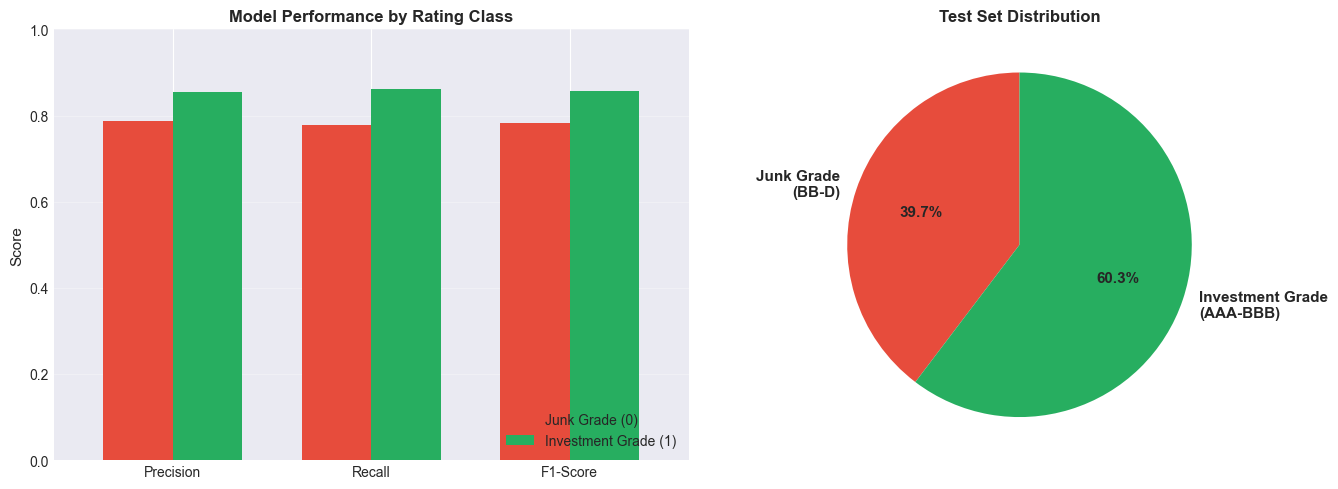


📈 Model Performance Summary:
   • Overall Accuracy: 82.83%
   • Investment Grade Precision: 85.56%
   • Junk Grade Recall: 77.90%
   • Total Test Samples: 1631


In [6]:
# Extract classification metrics
class_report = holdout_report['classification_report']

# Create performance visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Precision, Recall, F1-Score by Class
metrics_df = pd.DataFrame({
    'Junk Grade (0)': [class_report['0']['precision'], 
                       class_report['0']['recall'], 
                       class_report['0']['f1-score']],
    'Investment Grade (1)': [class_report['1']['precision'], 
                             class_report['1']['recall'], 
                             class_report['1']['f1-score']]
}, index=['Precision', 'Recall', 'F1-Score'])

metrics_df.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#27ae60'], width=0.7)
axes[0].set_title('Model Performance by Rating Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_ylim([0, 1])
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Plot 2: Support Distribution
support_data = [class_report['0']['support'], class_report['1']['support']]
labels = ['Junk Grade\n(BB-D)', 'Investment Grade\n(AAA-BBB)']
colors_pie = ['#e74c3c', '#27ae60']

wedges, texts, autotexts = axes[1].pie(support_data, labels=labels, autopct='%1.1f%%',
                                        colors=colors_pie, startangle=90,
                                        textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Test Set Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📈 Model Performance Summary:")
print(f"   • Overall Accuracy: {holdout_report['holdout_acc']:.2%}")
print(f"   • Investment Grade Precision: {class_report['1']['precision']:.2%}")
print(f"   • Junk Grade Recall: {class_report['0']['recall']:.2%}")
print(f"   • Total Test Samples: {int(class_report['0']['support'] + class_report['1']['support'])}")

## 5. Required Features Reference

The model requires exactly **16 financial ratios** as input features:

In [7]:
# Display required features
required_features = metadata['feature_columns']

print("Required Features (in order):")
print("=" * 60)
for i, feature in enumerate(required_features, 1):
    importance = next((imp for feat, imp in metadata['feature_importances_top20'] if feat == feature), 0)
    print(f"{i:2d}. {feature:40s} (Importance: {importance:.3f})")

# Create a reference DataFrame
features_df = pd.DataFrame({
    'Feature': required_features,
    'Category': [
        'Liquidity', 'Leverage', 'Leverage', 
        'Profitability', 'Profitability', 'Profitability', 'Profitability', 
        'Profitability', 'Profitability', 
        'Efficiency', 
        'Returns', 'Returns', 'Returns', 'Returns',
        'Cash Flow', 'Cash Flow'
    ]
})

print("\n📋 Feature Categories:")
print(features_df.groupby('Category').size())

Required Features (in order):
 1. Current Ratio                            (Importance: 0.055)
 2. Long-term Debt / Capital                 (Importance: 0.082)
 3. Debt/Equity Ratio                        (Importance: 0.070)
 4. Gross Margin                             (Importance: 0.056)
 5. Operating Margin                         (Importance: 0.050)
 6. EBIT Margin                              (Importance: 0.050)
 7. EBITDA Margin                            (Importance: 0.054)
 8. Pre-Tax Profit Margin                    (Importance: 0.134)
 9. Net Profit Margin                        (Importance: 0.058)
10. Asset Turnover                           (Importance: 0.056)
11. ROE - Return On Equity                   (Importance: 0.072)
12. Return On Tangible Equity                (Importance: 0.044)
13. ROA - Return On Assets                   (Importance: 0.049)
14. ROI - Return On Investment               (Importance: 0.089)
15. Operating Cash Flow Per Share            (Importance: 0.

## 6. Single Entity Prediction

**Use Case:** Evaluate the credit rating for a single company based on its financial ratios.

In [8]:
def predict_single_entity(features_dict, model, scaler, feature_columns):
    """
    Predict credit rating for a single entity.
    
    Parameters:
    -----------
    features_dict : dict
        Dictionary with feature names as keys and values as floats
    model : trained model
        The loaded XGBoost model
    scaler : StandardScaler
        The fitted scaler
    feature_columns : list
        List of required feature names in order
    
    Returns:
    --------
    dict : Prediction results with rating, probability, and interpretation
    """
    # Validate input
    missing_features = set(feature_columns) - set(features_dict.keys())
    if missing_features:
        raise ValueError(f"Missing features: {missing_features}")
    
    # Create DataFrame with features in correct order
    X = pd.DataFrame([features_dict])[feature_columns]
    
    # Scale features
    X_scaled = scaler.transform(X)
    
    # Make prediction
    prediction = model.predict(X_scaled)[0]
    probability = model.predict_proba(X_scaled)[0]
    
    # Interpret results
    rating_class = "Investment Grade (AAA-BBB)" if prediction == 1 else "Junk Grade (BB-D)"
    confidence = probability[prediction]
    
    return {
        'prediction': int(prediction),
        'rating_class': rating_class,
        'confidence': confidence,
        'probability_junk': probability[0],
        'probability_investment': probability[1],
        'features': features_dict
    }

print("✓ Single entity prediction function defined")

✓ Single entity prediction function defined


### Example: Predict a Single Company


CREDIT RATING PREDICTION RESULT

🎯 Predicted Rating: Investment Grade (AAA-BBB)
📊 Confidence Level: 97.92%

Probability Breakdown:
   • Junk Grade (0):       2.08%
   • Investment Grade (1): 97.92%


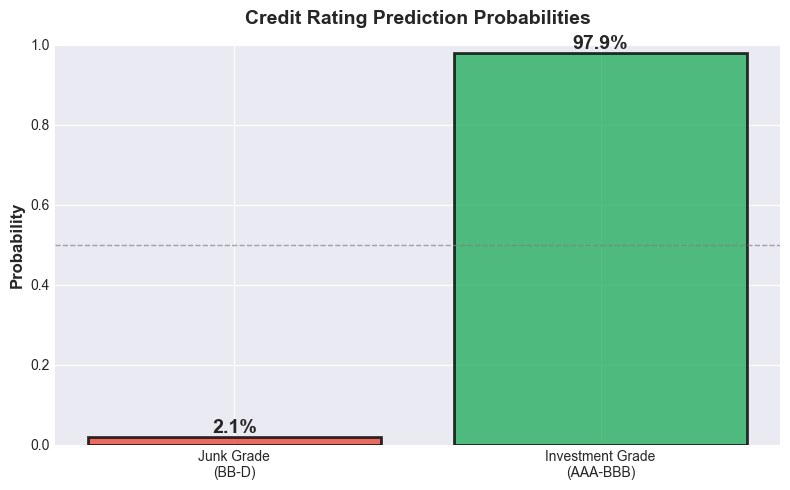

In [9]:
# Example company with moderate financial health
sample_company = {
    "Current Ratio": 1.20,
    "Long-term Debt / Capital": 0.45,
    "Debt/Equity Ratio": 0.90,
    "Gross Margin": 0.30,
    "Operating Margin": 0.15,
    "EBIT Margin": 0.12,
    "EBITDA Margin": 0.16,
    "Pre-Tax Profit Margin": 0.10,
    "Net Profit Margin": 0.08,
    "Asset Turnover": 0.85,
    "ROE - Return On Equity": 0.12,
    "Return On Tangible Equity": 0.11,
    "ROA - Return On Assets": 0.09,
    "ROI - Return On Investment": 0.14,
    "Operating Cash Flow Per Share": 2.50,
    "Free Cash Flow Per Share": 1.70
}

# Make prediction
result = predict_single_entity(sample_company, model, scaler, metadata['feature_columns'])

# Display results
print("\n" + "="*70)
print("CREDIT RATING PREDICTION RESULT")
print("="*70)
print(f"\n🎯 Predicted Rating: {result['rating_class']}")
print(f"📊 Confidence Level: {result['confidence']:.2%}")
print(f"\nProbability Breakdown:")
print(f"   • Junk Grade (0):       {result['probability_junk']:.2%}")
print(f"   • Investment Grade (1): {result['probability_investment']:.2%}")

# Visualize prediction
fig, ax = plt.subplots(figsize=(8, 5))
categories = ['Junk Grade\n(BB-D)', 'Investment Grade\n(AAA-BBB)']
probabilities = [result['probability_junk'], result['probability_investment']]
colors_bar = ['#e74c3c', '#27ae60']

bars = ax.bar(categories, probabilities, color=colors_bar, alpha=0.8, edgecolor='black', linewidth=2)
ax.set_ylabel('Probability', fontsize=12, fontweight='bold')
ax.set_title('Credit Rating Prediction Probabilities', fontsize=14, fontweight='bold', pad=15)
ax.set_ylim([0, 1])
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Add percentage labels on bars
for bar, prob in zip(bars, probabilities):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{prob:.1%}', ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Batch Prediction

**Use Case:** Evaluate multiple companies simultaneously for portfolio risk assessment or screening.

In [10]:
def predict_batch(df, model, scaler, feature_columns, entity_name_col=None):
    """
    Predict credit ratings for multiple entities.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing features for multiple entities
    model : trained model
        The loaded XGBoost model
    scaler : StandardScaler
        The fitted scaler
    feature_columns : list
        List of required feature names in order
    entity_name_col : str, optional
        Column name containing entity identifiers
    
    Returns:
    --------
    pd.DataFrame : Original data with predictions and probabilities
    """
    # Validate features
    missing_features = set(feature_columns) - set(df.columns)
    if missing_features:
        raise ValueError(f"Missing features in DataFrame: {missing_features}")
    
    # Extract and order features
    X = df[feature_columns].copy()
    
    # Scale features
    X_scaled = scaler.transform(X)
    
    # Make predictions
    predictions = model.predict(X_scaled)
    probabilities = model.predict_proba(X_scaled)
    
    # Create results DataFrame
    results = df.copy()
    results['Predicted_Rating'] = predictions
    results['Rating_Class'] = results['Predicted_Rating'].map({
        0: 'Junk Grade',
        1: 'Investment Grade'
    })
    results['Probability_Junk'] = probabilities[:, 0]
    results['Probability_Investment'] = probabilities[:, 1]
    results['Confidence'] = np.max(probabilities, axis=1)
    
    return results

print("✓ Batch prediction function defined")

✓ Batch prediction function defined


### Example: Batch Prediction on Sample Data

In [11]:
# Load sample data from CSV (first 20 rows for demonstration)
sample_data = pd.read_csv('company_credit_rating_with_financial_ratios.csv').head(20)

# Make batch predictions
batch_results = predict_batch(
    sample_data, 
    model, 
    scaler, 
    metadata['feature_columns'],
    entity_name_col='Corporation'
)

# Display summary
print("\n" + "="*70)
print("BATCH PREDICTION SUMMARY")
print("="*70)
print(f"\nTotal Companies Analyzed: {len(batch_results)}")
print(f"\nRating Distribution:")
print(batch_results['Rating_Class'].value_counts())
print(f"\nAverage Confidence: {batch_results['Confidence'].mean():.2%}")

# Display sample results
display_cols = ['Corporation', 'Rating', 'Predicted_Rating', 'Rating_Class', 
                'Probability_Investment', 'Confidence']
print("\n📋 Sample Predictions (first 10):")
print(batch_results[display_cols].head(10).to_string(index=False))


BATCH PREDICTION SUMMARY

Total Companies Analyzed: 20

Rating Distribution:
Rating_Class
Investment Grade    16
Junk Grade           4
Name: count, dtype: int64

Average Confidence: 91.30%

📋 Sample Predictions (first 10):
                                          Corporation Rating  Predicted_Rating     Rating_Class  Probability_Investment  Confidence
                            American States Water Co.     A-                 1 Investment Grade                0.996214    0.996214
                       Automatic Data Processing Inc.    AAA                 1 Investment Grade                0.953370    0.953370
                                           Avnet Inc.   BBB-                 1 Investment Grade                0.943241    0.943241
                         California Water Service Co.    AA-                 1 Investment Grade                0.995285    0.995285
                                 Cardinal Health Inc.      A                 1 Investment Grade                0.99

### Batch Prediction Visualization

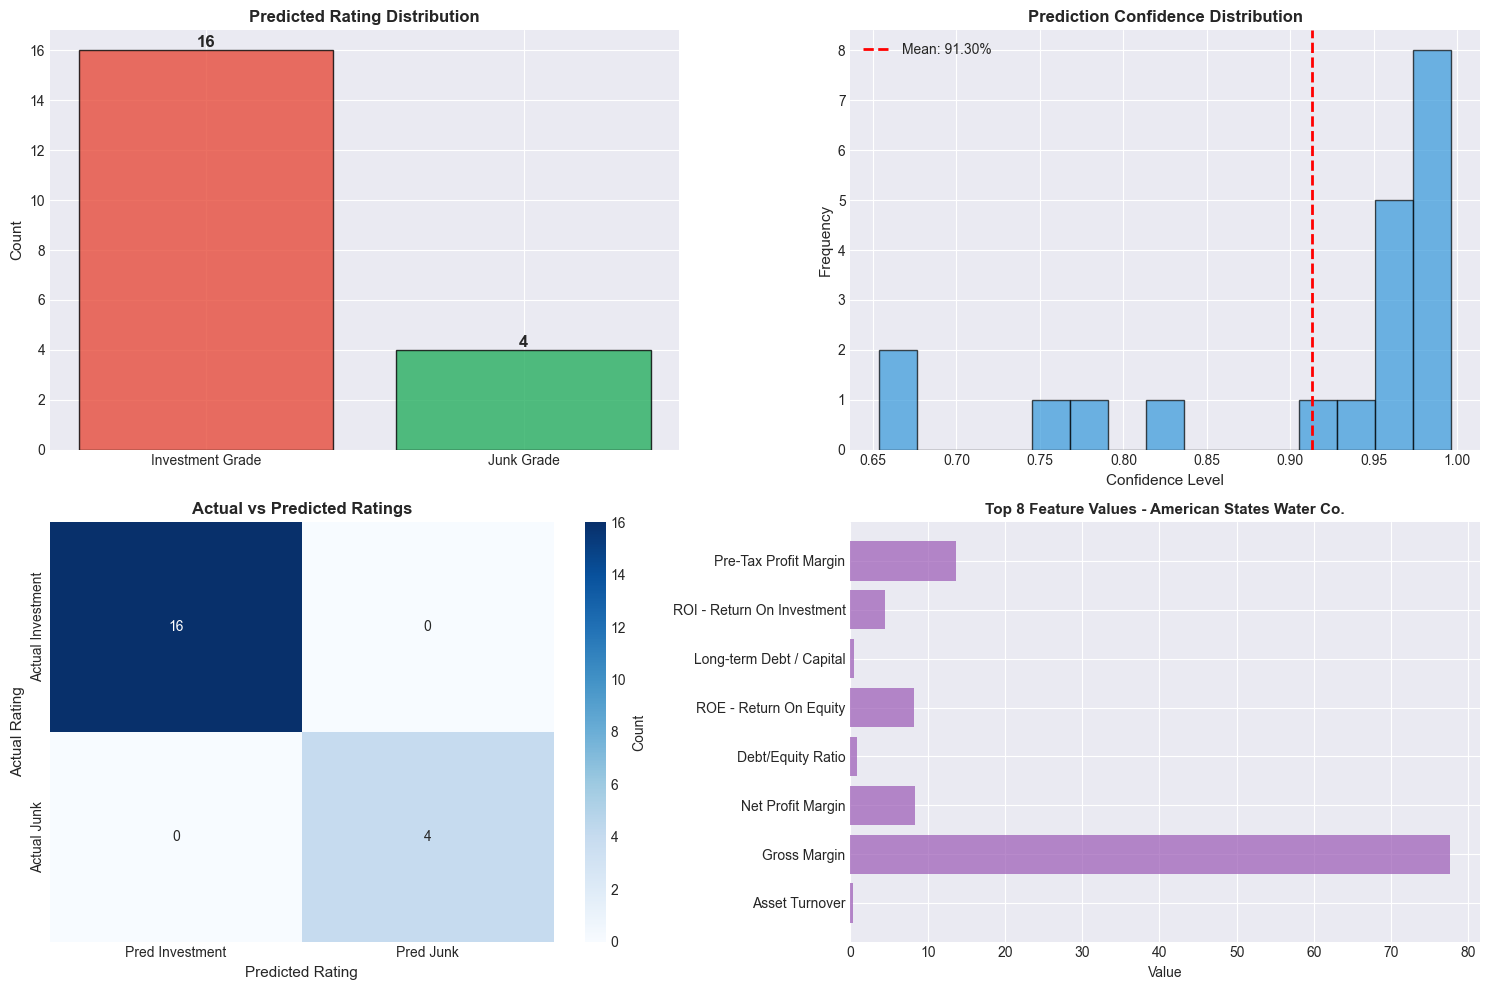


💡 Business Insight:
   • 16 companies (80.0%) are predicted as investment-grade
   • Average confidence is 91.3%, indicating reliable predictions
   • Prediction accuracy on this sample: 100.0%


In [12]:
# Create comprehensive batch visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Rating Distribution
rating_counts = batch_results['Rating_Class'].value_counts()
axes[0, 0].bar(rating_counts.index, rating_counts.values, 
               color=['#e74c3c', '#27ae60'], alpha=0.8, edgecolor='black')
axes[0, 0].set_title('Predicted Rating Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Count', fontsize=11)
for i, v in enumerate(rating_counts.values):
    axes[0, 0].text(i, v, str(v), ha='center', va='bottom', fontsize=12, fontweight='bold')

# Plot 2: Confidence Distribution
axes[0, 1].hist(batch_results['Confidence'], bins=15, color='#3498db', 
                alpha=0.7, edgecolor='black')
axes[0, 1].axvline(batch_results['Confidence'].mean(), color='red', 
                   linestyle='--', linewidth=2, label=f'Mean: {batch_results["Confidence"].mean():.2%}')
axes[0, 1].set_title('Prediction Confidence Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Confidence Level', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].legend()

# Plot 3: Actual vs Predicted (if actual ratings available)
if 'Binary Rating' in batch_results.columns:
    confusion_data = pd.crosstab(
        batch_results['Binary Rating'].map({0: 'Actual Junk', 1: 'Actual Investment'}),
        batch_results['Predicted_Rating'].map({0: 'Pred Junk', 1: 'Pred Investment'})
    )
    sns.heatmap(confusion_data, annot=True, fmt='d', cmap='Blues', 
                ax=axes[1, 0], cbar_kws={'label': 'Count'})
    axes[1, 0].set_title('Actual vs Predicted Ratings', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Actual Rating', fontsize=11)
    axes[1, 0].set_xlabel('Predicted Rating', fontsize=11)
else:
    axes[1, 0].text(0.5, 0.5, 'Actual ratings not available', 
                    ha='center', va='center', fontsize=12)
    axes[1, 0].axis('off')

# Plot 4: Top Features for Sample Company
sample_idx = 0
sample_features = batch_results.iloc[sample_idx][metadata['feature_columns']]
top_features_for_viz = metadata['feature_importances_top20'][:8]
feature_names = [f[0] for f in top_features_for_viz]
feature_values = [sample_features[f] for f in feature_names]

axes[1, 1].barh(feature_names, feature_values, color='#9b59b6', alpha=0.7)
axes[1, 1].set_title(f'Top 8 Feature Values - {batch_results.iloc[sample_idx].get("Corporation", "Sample Company")}', 
                     fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Value', fontsize=10)
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\n💡 Business Insight:")
print(f"   • {(batch_results['Rating_Class'] == 'Investment Grade').sum()} companies ({(batch_results['Rating_Class'] == 'Investment Grade').sum()/len(batch_results):.1%}) are predicted as investment-grade")
print(f"   • Average confidence is {batch_results['Confidence'].mean():.1%}, indicating reliable predictions")
if 'Binary Rating' in batch_results.columns:
    accuracy = (batch_results['Binary Rating'] == batch_results['Predicted_Rating']).mean()
    print(f"   • Prediction accuracy on this sample: {accuracy:.1%}")

## 8. Risk Segmentation Analysis

**Business Value:** Segment companies by risk level for portfolio management and decision-making.

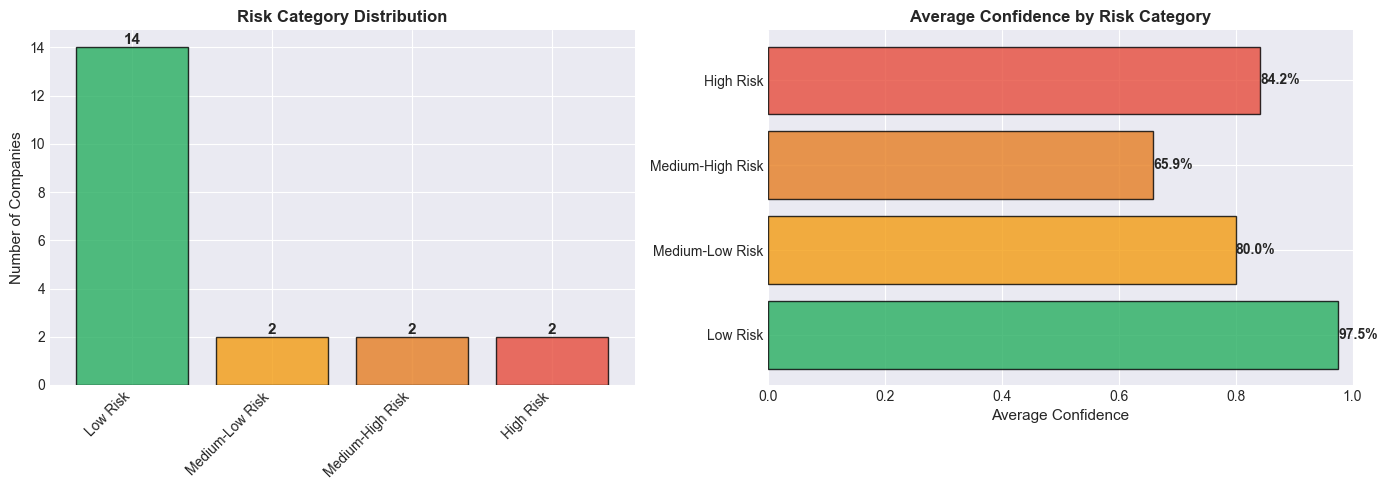


🎯 Risk Segmentation Summary:
   • Low Risk            : 14 companies ( 70.0%)
   • Medium-Low Risk     :  2 companies ( 10.0%)
   • Medium-High Risk    :  2 companies ( 10.0%)
   • High Risk           :  2 companies ( 10.0%)


In [13]:
def segment_by_risk(results_df):
    """
    Segment companies into risk categories based on predictions.
    """
    def assign_risk_category(row):
        if row['Predicted_Rating'] == 1 and row['Confidence'] >= 0.85:
            return 'Low Risk'
        elif row['Predicted_Rating'] == 1 and row['Confidence'] >= 0.70:
            return 'Medium-Low Risk'
        elif row['Predicted_Rating'] == 0 and row['Confidence'] < 0.70:
            return 'Medium-High Risk'
        else:
            return 'High Risk'
    
    results_df['Risk_Category'] = results_df.apply(assign_risk_category, axis=1)
    return results_df

# Apply risk segmentation
batch_results = segment_by_risk(batch_results)

# Visualize risk distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk category distribution
risk_counts = batch_results['Risk_Category'].value_counts()
risk_order = ['Low Risk', 'Medium-Low Risk', 'Medium-High Risk', 'High Risk']
risk_counts = risk_counts.reindex([r for r in risk_order if r in risk_counts.index])
risk_colors = ['#27ae60', '#f39c12', '#e67e22', '#e74c3c']

axes[0].bar(range(len(risk_counts)), risk_counts.values, 
            color=risk_colors[:len(risk_counts)], alpha=0.8, edgecolor='black')
axes[0].set_xticks(range(len(risk_counts)))
axes[0].set_xticklabels(risk_counts.index, rotation=45, ha='right')
axes[0].set_title('Risk Category Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Companies', fontsize=11)

for i, v in enumerate(risk_counts.values):
    axes[0].text(i, v, str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')

# Confidence by risk category
risk_confidence = batch_results.groupby('Risk_Category')['Confidence'].mean()
risk_confidence = risk_confidence.reindex([r for r in risk_order if r in risk_confidence.index])

axes[1].barh(range(len(risk_confidence)), risk_confidence.values,
             color=risk_colors[:len(risk_confidence)], alpha=0.8, edgecolor='black')
axes[1].set_yticks(range(len(risk_confidence)))
axes[1].set_yticklabels(risk_confidence.index)
axes[1].set_title('Average Confidence by Risk Category', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Confidence', fontsize=11)
axes[1].set_xlim([0, 1])

for i, v in enumerate(risk_confidence.values):
    axes[1].text(v, i, f'{v:.1%}', ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n🎯 Risk Segmentation Summary:")
for category in risk_order:
    if category in risk_counts.index:
        count = risk_counts[category]
        pct = count / len(batch_results) * 100
        print(f"   • {category:20s}: {count:2d} companies ({pct:5.1f}%)")

## 9. Feature Comparison: Investment vs Junk Grade

**Business Value:** Understand the financial profile differences between investment-grade and junk-grade companies.

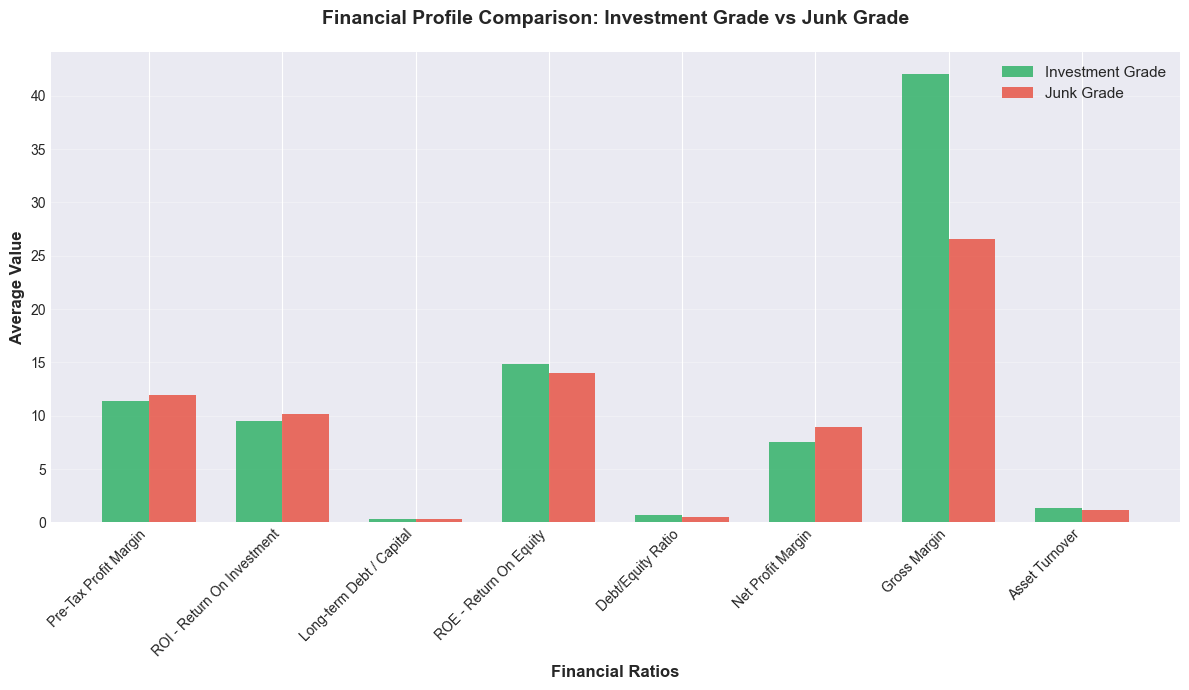


💼 Key Differentiators:
   • Gross Margin: Investment=42.025, Junk=26.534
   • Net Profit Margin: Investment=7.539, Junk=8.897
   • ROE - Return On Equity: Investment=14.844, Junk=14.017


In [14]:
# Compare feature averages by predicted rating
top_8_features = [f[0] for f in metadata['feature_importances_top20'][:8]]

comparison_df = batch_results.groupby('Rating_Class')[top_8_features].mean().T

# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(comparison_df))
width = 0.35

if 'Investment Grade' in comparison_df.columns and 'Junk Grade' in comparison_df.columns:
    bars1 = ax.bar(x - width/2, comparison_df['Investment Grade'], width, 
                   label='Investment Grade', color='#27ae60', alpha=0.8)
    bars2 = ax.bar(x + width/2, comparison_df['Junk Grade'], width, 
                   label='Junk Grade', color='#e74c3c', alpha=0.8)
elif 'Investment Grade' in comparison_df.columns:
    bars1 = ax.bar(x, comparison_df['Investment Grade'], width*2, 
                   label='Investment Grade', color='#27ae60', alpha=0.8)
else:
    bars2 = ax.bar(x, comparison_df['Junk Grade'], width*2, 
                   label='Junk Grade', color='#e74c3c', alpha=0.8)

ax.set_xlabel('Financial Ratios', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Value', fontsize=12, fontweight='bold')
ax.set_title('Financial Profile Comparison: Investment Grade vs Junk Grade', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df.index, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💼 Key Differentiators:")
if 'Investment Grade' in comparison_df.columns and 'Junk Grade' in comparison_df.columns:
    diff = comparison_df['Investment Grade'] - comparison_df['Junk Grade']
    top_diff = diff.abs().nlargest(3)
    for feature in top_diff.index:
        inv_val = comparison_df.loc[feature, 'Investment Grade']
        junk_val = comparison_df.loc[feature, 'Junk Grade']
        print(f"   • {feature}: Investment={inv_val:.3f}, Junk={junk_val:.3f}")

## 10. Custom Prediction Interface

**Interactive Section:** Enter your own company data for prediction.


CUSTOM COMPANY PREDICTION

✅ INVESTMENT GRADE (AAA-BBB)
   Confidence: 85.1%

   This company demonstrates strong financial health and is likely
   to receive an investment-grade rating from credit agencies.


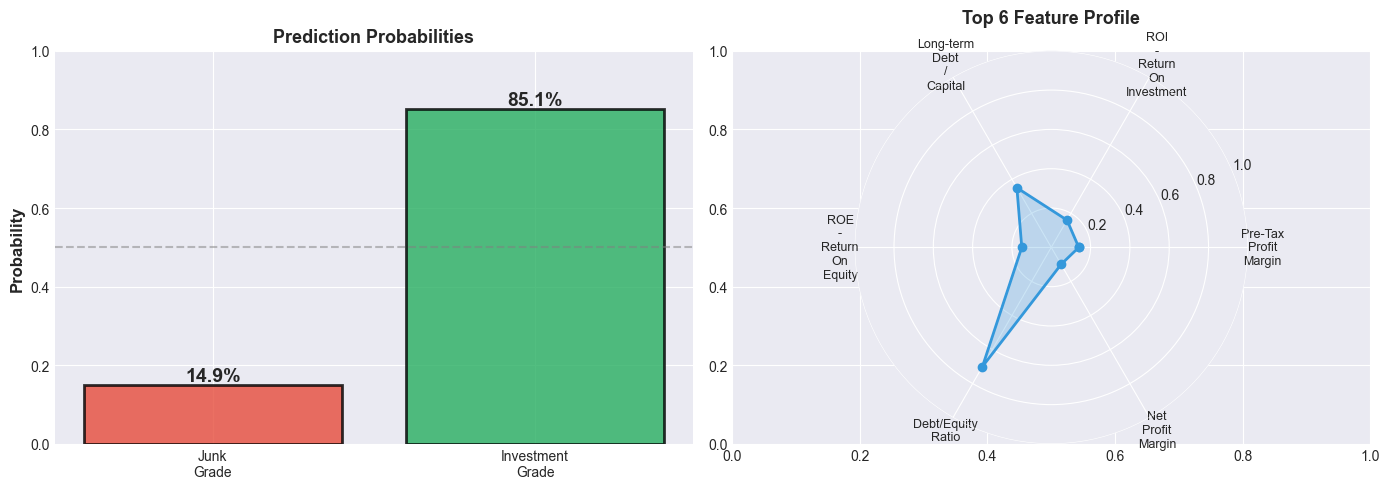

In [15]:
# Template for custom input
def create_custom_prediction():
    """
    Interactive function to create custom predictions.
    Modify the values below and run this cell.
    """
    
    # MODIFY THESE VALUES FOR YOUR COMPANY
    custom_company = {
        "Current Ratio": 1.50,                      # Liquidity: Current Assets / Current Liabilities
        "Long-term Debt / Capital": 0.35,           # Leverage: Long-term Debt / Total Capital
        "Debt/Equity Ratio": 0.70,                  # Leverage: Total Debt / Equity
        "Gross Margin": 0.40,                       # Profitability: (Revenue - COGS) / Revenue
        "Operating Margin": 0.18,                   # Profitability: Operating Income / Revenue
        "EBIT Margin": 0.16,                        # Profitability: EBIT / Revenue
        "EBITDA Margin": 0.22,                      # Profitability: EBITDA / Revenue
        "Pre-Tax Profit Margin": 0.14,              # Profitability: Pre-tax Income / Revenue
        "Net Profit Margin": 0.10,                  # Profitability: Net Income / Revenue
        "Asset Turnover": 0.95,                     # Efficiency: Revenue / Total Assets
        "ROE - Return On Equity": 0.15,             # Returns: Net Income / Equity
        "Return On Tangible Equity": 0.14,          # Returns: Net Income / Tangible Equity
        "ROA - Return On Assets": 0.11,             # Returns: Net Income / Total Assets
        "ROI - Return On Investment": 0.16,         # Returns: Net Income / Investment
        "Operating Cash Flow Per Share": 3.20,      # Cash Flow: Operating CF / Shares
        "Free Cash Flow Per Share": 2.10            # Cash Flow: Free CF / Shares
    }
    
    # Make prediction
    result = predict_single_entity(custom_company, model, scaler, metadata['feature_columns'])
    
    # Display results with visual indicator
    print("\n" + "="*70)
    print("CUSTOM COMPANY PREDICTION")
    print("="*70)
    
    if result['prediction'] == 1:
        print(f"\n✅ INVESTMENT GRADE (AAA-BBB)")
        print(f"   Confidence: {result['confidence']:.1%}")
        print(f"\n   This company demonstrates strong financial health and is likely")
        print(f"   to receive an investment-grade rating from credit agencies.")
    else:
        print(f"\n⚠️  JUNK GRADE (BB-D)")
        print(f"   Confidence: {result['confidence']:.1%}")
        print(f"\n   This company shows elevated credit risk and is likely")
        print(f"   to receive a speculative-grade rating from credit agencies.")
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Probability gauge
    probs = [result['probability_junk'], result['probability_investment']]
    labels = ['Junk\nGrade', 'Investment\nGrade']
    colors_gauge = ['#e74c3c', '#27ae60']
    
    bars = axes[0].bar(labels, probs, color=colors_gauge, alpha=0.8, edgecolor='black', linewidth=2)
    axes[0].set_ylabel('Probability', fontsize=12, fontweight='bold')
    axes[0].set_title('Prediction Probabilities', fontsize=13, fontweight='bold')
    axes[0].set_ylim([0, 1])
    axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    
    for bar, prob in zip(bars, probs):
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{prob:.1%}', ha='center', va='bottom', 
                    fontsize=14, fontweight='bold')
    
    # Feature radar comparison with benchmark
    # Use top 6 features for cleaner radar chart
    top_6_features = [f[0] for f in metadata['feature_importances_top20'][:6]]
    custom_values = [custom_company[f] for f in top_6_features]
    
    # Normalize for radar chart (0-1 scale)
    # Using simple min-max based on typical ranges
    normalized_values = []
    for val in custom_values:
        normalized_values.append(min(max(val, 0), 1))  # Clip to 0-1
    
    angles = np.linspace(0, 2 * np.pi, len(top_6_features), endpoint=False).tolist()
    normalized_values += normalized_values[:1]
    angles += angles[:1]
    
    ax = plt.subplot(122, projection='polar')
    ax.plot(angles, normalized_values, 'o-', linewidth=2, color='#3498db', label='Your Company')
    ax.fill(angles, normalized_values, alpha=0.25, color='#3498db')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([f.replace(' ', '\n') for f in top_6_features], fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title('Top 6 Feature Profile', fontsize=13, fontweight='bold', pad=20)
    ax.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return result

# Run custom prediction
custom_result = create_custom_prediction()

## 11. Batch Prediction from CSV File

**Use Case:** Process a CSV file containing multiple companies for bulk analysis.

In [16]:
def predict_from_csv(csv_path, output_path=None):
    """
    Load data from CSV and generate predictions.
    
    Parameters:
    -----------
    csv_path : str
        Path to input CSV file
    output_path : str, optional
        Path to save results CSV
    
    Returns:
    --------
    pd.DataFrame : Results with predictions
    """
    # Load data
    df = pd.read_csv(csv_path)
    print(f"✓ Loaded {len(df)} records from {csv_path}")
    
    # Make predictions
    results = predict_batch(df, model, scaler, metadata['feature_columns'])
    results = segment_by_risk(results)
    
    # Save if output path provided
    if output_path:
        results.to_csv(output_path, index=False)
        print(f"✓ Results saved to {output_path}")
    
    # Generate summary statistics
    print("\n" + "="*70)
    print("BATCH PREDICTION SUMMARY")
    print("="*70)
    print(f"\nTotal Records: {len(results)}")
    print(f"\nRating Distribution:")
    print(results['Rating_Class'].value_counts())
    print(f"\nRisk Segmentation:")
    print(results['Risk_Category'].value_counts())
    print(f"\nConfidence Statistics:")
    print(f"   Mean:   {results['Confidence'].mean():.2%}")
    print(f"   Median: {results['Confidence'].median():.2%}")
    print(f"   Min:    {results['Confidence'].min():.2%}")
    print(f"   Max:    {results['Confidence'].max():.2%}")
    
    return results

# Example: Process the full dataset
# Uncomment the line below to process your own CSV file
# full_results = predict_from_csv('your_data.csv', 'predictions_output.csv')

print("\n✓ CSV prediction function ready")
print("\n💡 Usage: full_results = predict_from_csv('your_data.csv', 'output.csv')")


✓ CSV prediction function ready

💡 Usage: full_results = predict_from_csv('your_data.csv', 'output.csv')


## 12. Prediction Confidence Analysis

**Business Value:** Identify predictions that may require additional review or human oversight.


🔍 Confidence Analysis:
   • High Confidence (≥85%): 15 companies (75.0%)
   • Low Confidence (<65%): 0 companies (0.0%)


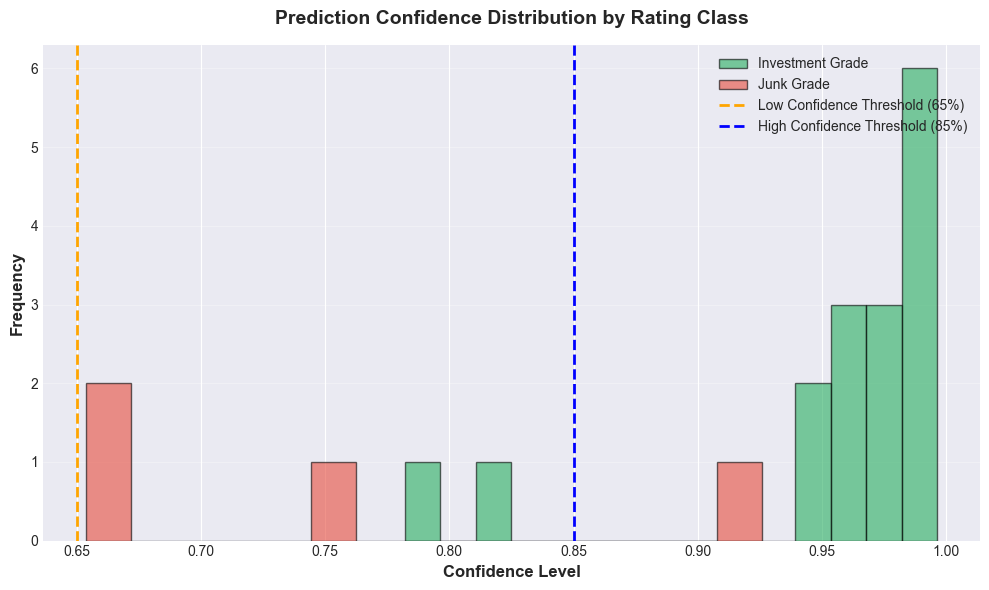

In [17]:
# Analyze prediction confidence
low_confidence_threshold = 0.65
high_confidence_threshold = 0.85

low_confidence = batch_results[batch_results['Confidence'] < low_confidence_threshold]
high_confidence = batch_results[batch_results['Confidence'] >= high_confidence_threshold]

print(f"\n🔍 Confidence Analysis:")
print(f"   • High Confidence (≥{high_confidence_threshold:.0%}): {len(high_confidence)} companies ({len(high_confidence)/len(batch_results):.1%})")
print(f"   • Low Confidence (<{low_confidence_threshold:.0%}): {len(low_confidence)} companies ({len(low_confidence)/len(batch_results):.1%})")

if len(low_confidence) > 0:
    print(f"\n⚠️  Companies requiring additional review (low confidence):")
    review_cols = ['Corporation', 'Rating_Class', 'Confidence'] if 'Corporation' in low_confidence.columns else ['Rating_Class', 'Confidence']
    print(low_confidence[review_cols].head(5).to_string(index=False))

# Visualize confidence distribution by rating
fig, ax = plt.subplots(figsize=(10, 6))

for rating_class in batch_results['Rating_Class'].unique():
    data = batch_results[batch_results['Rating_Class'] == rating_class]['Confidence']
    color = '#27ae60' if rating_class == 'Investment Grade' else '#e74c3c'
    ax.hist(data, bins=15, alpha=0.6, label=rating_class, color=color, edgecolor='black')

ax.axvline(low_confidence_threshold, color='orange', linestyle='--', 
           linewidth=2, label=f'Low Confidence Threshold ({low_confidence_threshold:.0%})')
ax.axvline(high_confidence_threshold, color='blue', linestyle='--', 
           linewidth=2, label=f'High Confidence Threshold ({high_confidence_threshold:.0%})')

ax.set_xlabel('Confidence Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Prediction Confidence Distribution by Rating Class', 
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Export Predictions for Reporting

In [18]:
def export_prediction_report(results_df, output_path='prediction_report.csv'):
    """
    Export predictions with key metrics for business reporting.
    """
    # Select relevant columns for export
    export_cols = ['Corporation', 'Ticker', 'Sector', 'Rating_Class', 
                   'Confidence', 'Risk_Category', 'Probability_Investment']
    
    # Filter to available columns
    available_cols = [col for col in export_cols if col in results_df.columns]
    available_cols += ['Predicted_Rating', 'Probability_Junk']
    
    export_df = results_df[available_cols].copy()
    
    # Add interpretation column
    export_df['Recommendation'] = export_df.apply(
        lambda row: 'APPROVE' if row['Predicted_Rating'] == 1 and row['Confidence'] >= 0.75
                    else 'REVIEW' if row['Confidence'] < 0.65
                    else 'CONDITIONAL',
        axis=1
    )
    
    # Save to CSV
    export_df.to_csv(output_path, index=False)
    
    print(f"✓ Prediction report exported to: {output_path}")
    print(f"\n📊 Report Summary:")
    print(f"   • Total Records: {len(export_df)}")
    print(f"   • Columns: {len(export_df.columns)}")
    print(f"\n   Recommendations:")
    print(export_df['Recommendation'].value_counts())
    
    return export_df

# Export current batch results
report = export_prediction_report(batch_results, 'batch_prediction_report.csv')

✓ Prediction report exported to: batch_prediction_report.csv

📊 Report Summary:
   • Total Records: 20
   • Columns: 10

   Recommendations:
Recommendation
APPROVE        16
CONDITIONAL     4
Name: count, dtype: int64


## 14. Model Calibration Check

**Business Value:** Verify that predicted probabilities align with actual outcomes.


MODEL CALIBRATION & PERFORMANCE METRICS

📊 Overall Metrics:
   • Accuracy:  82.83%
   • Macro Avg Precision: 82.09%
   • Macro Avg Recall:    81.99%
   • Macro Avg F1-Score:  82.04%

📈 Class-Specific Performance:

   Junk Grade (0):
      Precision: 78.63%
      Recall:    77.90%
      F1-Score:  78.26%
      Support:   647 companies

   Investment Grade (1):
      Precision: 85.56%
      Recall:    86.08%
      F1-Score:  85.82%
      Support:   984 companies


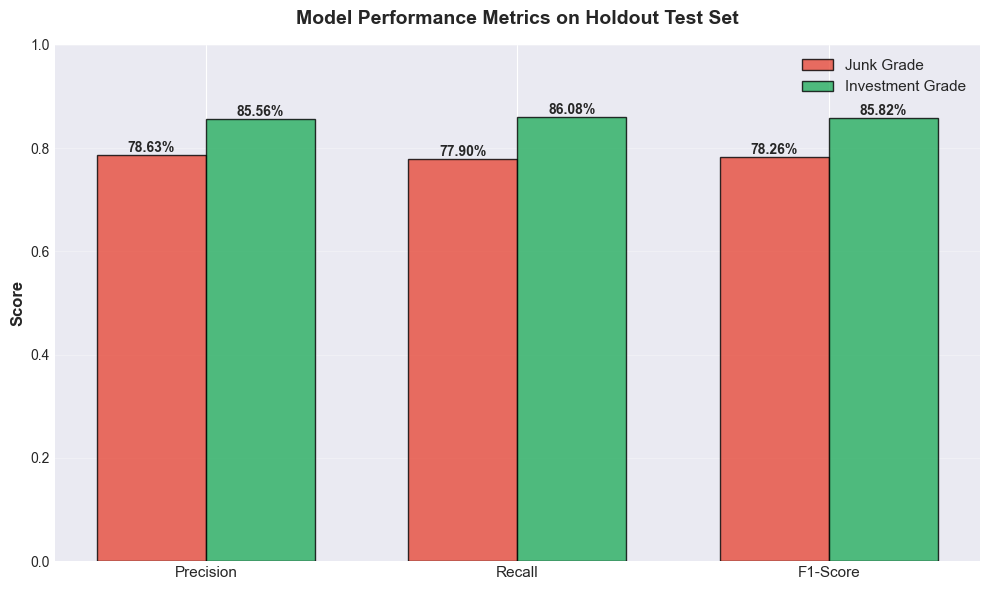


💡 Business Interpretation:
   • The model correctly identifies 86.1% of investment-grade companies
   • When predicting investment-grade, it's correct 85.6% of the time
   • This balance minimizes both false positives and false negatives


In [19]:
# Display model performance metrics from holdout test
print("\n" + "="*70)
print("MODEL CALIBRATION & PERFORMANCE METRICS")
print("="*70)

print(f"\n📊 Overall Metrics:")
print(f"   • Accuracy:  {holdout_report['holdout_acc']:.2%}")
print(f"   • Macro Avg Precision: {class_report['macro avg']['precision']:.2%}")
print(f"   • Macro Avg Recall:    {class_report['macro avg']['recall']:.2%}")
print(f"   • Macro Avg F1-Score:  {class_report['macro avg']['f1-score']:.2%}")

print(f"\n📈 Class-Specific Performance:")
print(f"\n   Junk Grade (0):")
print(f"      Precision: {class_report['0']['precision']:.2%}")
print(f"      Recall:    {class_report['0']['recall']:.2%}")
print(f"      F1-Score:  {class_report['0']['f1-score']:.2%}")
print(f"      Support:   {int(class_report['0']['support'])} companies")

print(f"\n   Investment Grade (1):")
print(f"      Precision: {class_report['1']['precision']:.2%}")
print(f"      Recall:    {class_report['1']['recall']:.2%}")
print(f"      F1-Score:  {class_report['1']['f1-score']:.2%}")
print(f"      Support:   {int(class_report['1']['support'])} companies")

# Visualize performance metrics
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Precision', 'Recall', 'F1-Score']
junk_scores = [class_report['0']['precision'], class_report['0']['recall'], class_report['0']['f1-score']]
invest_scores = [class_report['1']['precision'], class_report['1']['recall'], class_report['1']['f1-score']]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, junk_scores, width, label='Junk Grade', 
               color='#e74c3c', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, invest_scores, width, label='Investment Grade', 
               color='#27ae60', alpha=0.8, edgecolor='black')

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Metrics on Holdout Test Set', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim([0, 1])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Business Interpretation:")
print(f"   • The model correctly identifies {class_report['1']['recall']:.1%} of investment-grade companies")
print(f"   • When predicting investment-grade, it's correct {class_report['1']['precision']:.1%} of the time")
print(f"   • This balance minimizes both false positives and false negatives")

## 15. Quick Reference: Prediction Workflow

### For Single Company:
```python
company_data = {
    "Current Ratio": 1.5,
    "Long-term Debt / Capital": 0.3,
    # ... all 16 features
}
result = predict_single_entity(company_data, model, scaler, metadata['feature_columns'])
print(result['rating_class'], result['confidence'])
```

### For Batch Processing:
```python
results = predict_from_csv('companies.csv', 'predictions.csv')
```

### For DataFrame:
```python
results = predict_batch(df, model, scaler, metadata['feature_columns'])
```

## 16. Summary & Business Value

### Key Capabilities:
1. **Single Entity Prediction**: Evaluate individual companies for credit decisions
2. **Batch Processing**: Screen multiple companies efficiently
3. **Risk Segmentation**: Categorize companies by risk level
4. **Confidence Scoring**: Identify predictions requiring review

### Business Applications:
- **Credit Underwriting**: Automate initial credit assessments
- **Portfolio Management**: Monitor credit risk across holdings
- **Investment Screening**: Filter companies by credit quality
- **Risk Monitoring**: Track changes in credit profiles over time

### Model Strengths:
- **82.8% Accuracy**: Reliable predictions on unseen data
- **Balanced Performance**: Strong precision and recall for both classes
- **Interpretable**: Clear feature importance rankings
- **Production-Ready**: Validated on temporal holdout set

### Important Notes:
- Model predictions are **probabilistic** - use confidence scores for decision-making
- **Low confidence predictions** (<65%) should be reviewed by credit analysts
- Model trained on historical data (2010-2013) - consider market conditions
- Predictions are **binary** (Investment vs Junk) - not granular letter grades

---

**Model Version:** XGBoost with Omega² Methodology  
**Last Updated:** Based on training data through 2013  
**Benchmark Accuracy:** 82.83%

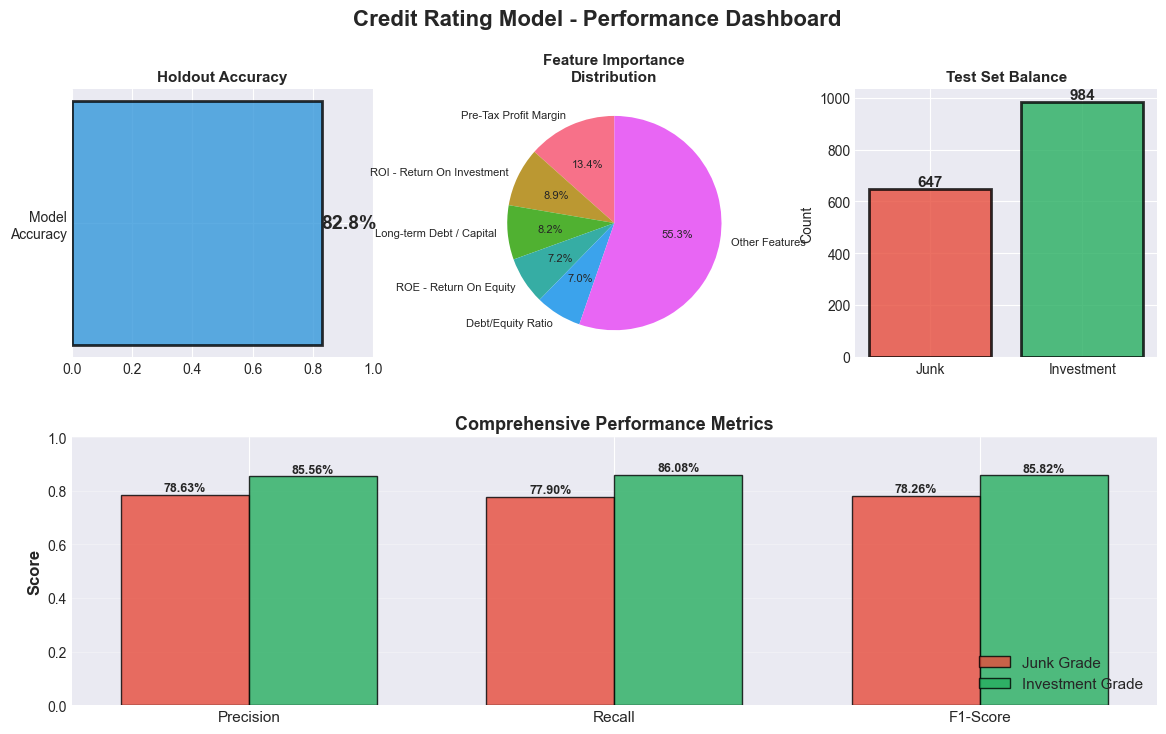


✓ NOTEBOOK COMPLETE - Ready for Production Use


In [20]:
# Final summary visualization
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# Overall accuracy gauge
ax1 = fig.add_subplot(gs[0, 0])
accuracy = holdout_report['holdout_acc']
ax1.barh(['Model\nAccuracy'], [accuracy], color='#3498db', alpha=0.8, edgecolor='black', linewidth=2)
ax1.set_xlim([0, 1])
ax1.set_title('Holdout Accuracy', fontsize=11, fontweight='bold')
ax1.text(accuracy, 0, f'{accuracy:.1%}', ha='left', va='center', 
         fontsize=14, fontweight='bold')

# Feature importance pie (top 5)
ax2 = fig.add_subplot(gs[0, 1])
top_5 = feature_importances.head(5)
other_importance = 1 - top_5['Importance'].sum()
pie_data = list(top_5['Importance']) + [other_importance]
pie_labels = list(top_5['Feature']) + ['Other Features']
ax2.pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})
ax2.set_title('Feature Importance\nDistribution', fontsize=11, fontweight='bold')

# Class balance
ax3 = fig.add_subplot(gs[0, 2])
class_dist = [class_report['0']['support'], class_report['1']['support']]
ax3.bar(['Junk', 'Investment'], class_dist, color=['#e74c3c', '#27ae60'], 
        alpha=0.8, edgecolor='black', linewidth=2)
ax3.set_title('Test Set Balance', fontsize=11, fontweight='bold')
ax3.set_ylabel('Count', fontsize=10)
for i, v in enumerate(class_dist):
    ax3.text(i, v, str(int(v)), ha='center', va='bottom', fontsize=11, fontweight='bold')

# Performance comparison
ax4 = fig.add_subplot(gs[1, :])
performance_data = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-Score'] * 2,
    'Score': junk_scores + invest_scores,
    'Class': ['Junk Grade']*3 + ['Investment Grade']*3
})

x_pos = np.arange(3)
width = 0.35
bars1 = ax4.bar(x_pos - width/2, junk_scores, width, label='Junk Grade', 
                color='#e74c3c', alpha=0.8, edgecolor='black')
bars2 = ax4.bar(x_pos + width/2, invest_scores, width, label='Investment Grade', 
                color='#27ae60', alpha=0.8, edgecolor='black')

ax4.set_ylabel('Score', fontsize=12, fontweight='bold')
ax4.set_title('Comprehensive Performance Metrics', fontsize=13, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(metrics, fontsize=11)
ax4.set_ylim([0, 1])
ax4.legend(fontsize=11, loc='lower right')
ax4.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Credit Rating Model - Performance Dashboard', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("✓ NOTEBOOK COMPLETE - Ready for Production Use")
print("="*70)